## Descripcion

Este cuaderno implementa el primer acercamiento al reconocimiento de comandos de voz utilizando
**Multi-Instance Learning (MIL)** con **LinearSVC como clasificador**. La idea central es tratar
cada audio como una *bolsa de instancias*, donde cada instancia es un frame temporal con sus
coeficientes MFCC. El modelo clasifica frames individuales y agrega esas predicciones por
votacion para decidir la etiqueta final del audio completo.

Trabajaremos con las mismas **6 palabras clave** definidas en la inicialmente:
**Up, Down, Left, Right, Stop y Go**.

### Concepto de Multi-Instance Learning (MIL)

En el paradigma MIL cada muestra de entrenamiento es una *bolsa* que contiene multiples instancias.
Para audio, esto se traduce en:

- **Bolsa:** un archivo de audio completo (1 segundo)
- **Instancia:** un frame de tiempo con su vector de MFCCs
- **Etiqueta:** la palabra pronunciada (up, down, left, right, stop, go)

El LinearSVC clasifica cada instancia individualmente y luego se agrega por votacion para
obtener la prediccion final de la bolsa.

### Acercamiento

1. **Preprocesamiento**: VAD (Voice Activity Detection), normalizacion, padding a 1 segundo
2. **Extraccion de caracteristicas**: MFCCs + deltas por cada frame -> instancias de la bolsa
3. **Aplanamiento MIL**: todas las instancias se apilan para entrenar el clasificador
4. **Entrenamiento LinearSVC**: clasifica cada frame como instancia independiente
5. **Agregacion**: votacion por mayoria sobre los frames de cada audio
6. **Evaluacion**: metricas a nivel de bolsa (nivel audio)

### Importaciones


In [21]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import webrtcvad

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, \
                             precision_score, recall_score, f1_score
from sklearn.decomposition import PCA

from collections import Counter
from tqdm import tqdm

print('Importaciones completadas exitosamente.')

Importaciones completadas exitosamente.


#### Configuraciones

Definimos las constantes que controlan el comportamiento del pipeline. Los valores de
`SAMPLE_RATE` y `TARGET_LENGTH` se ajustan a lo que confirmamos en la exploracion:
16000 Hz y 1 segundo exacto por muestra.


In [22]:
DEST_FOLDER = 'speech_commands'
TARGET_WORDS  = ['up', 'down', 'left', 'right', 'stop', 'go']


SAMPLE_RATE = 16000 # Hz, confirmado en la exploracion
TARGET_LENGTH = 16000 

# Extraccion MFCC
N_MFCC = 13
N_FFT = 512
HOP_LENGTH  = 256

VAD_AGGRESSIVENESS = 2
FRAME_DURATION_MS = 30

SVM_C = 0.1 
SVM_MAX_ITER = 2000

# --- Entrenamiento ---
RANDOM_STATE = 42
TEST_SIZE = 0.2

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Configuraciones establecidas:')
print(f'  - Palabras objetivo : {TARGET_WORDS}')
print(f'  - Sample Rate       : {SAMPLE_RATE} Hz')
print(f'  - MFCCs             : {N_MFCC} coeficientes base ({N_MFCC*3} con deltas)')
print(f'  - VAD agresividad   : {VAD_AGGRESSIVENESS}')
print(f'  - C LinearSVC       : {SVM_C}')

Configuraciones establecidas:
  - Palabras objetivo : ['up', 'down', 'left', 'right', 'stop', 'go']
  - Sample Rate       : 16000 Hz
  - MFCCs             : 13 coeficientes base (39 con deltas)
  - VAD agresividad   : 2
  - C LinearSVC       : 0.1


## Preprocesamiento de Audio

Antes de extraer caracteristicas necesitamos preparar cada audio. El pipeline tiene cuatro pasos:

1. **Carga**: leer el `.wav` y convertir a mono con la frecuencia de muestreo del dataset
2. **Normalizacion**: escalar la amplitud al rango `[-1, 1]` para uniformidad entre grabaciones
3. **VAD** *(Voice Activity Detection)*: recortar silencios usando WebRTC VAD;
   el silencio no aporta informacion discriminativa pero si ruido al modelo
4. **Padding / Truncamiento**: ajustar todos los audios a exactamente 1 segundo (16000 muestras)
   para garantizar bolsas del mismo tamano


In [23]:
def load_audio(filepath, sr=SAMPLE_RATE):
    try:
        audio, sr_loaded = librosa.load(filepath, sr=sr, mono=True)
        return audio, sr_loaded
    except Exception as e:
        print(f'Error al cargar {filepath}: {e}')
        return None, sr


def normalize_signal(audio):
    max_val = np.max(np.abs(audio))
    return audio / max_val if max_val > 0 else audio


def apply_vad(audio, sr=SAMPLE_RATE, aggressiveness=VAD_AGGRESSIVENESS,
              frame_duration_ms=FRAME_DURATION_MS):
    """
    Recorta silencios usando WebRTC VAD. Clasifica cada frame como voz/no-voz
    y descarta los frames silenciosos. Si el resultado queda por debajo de
    100ms (VAD fue demasiado agresivo) devuelve el audio original sin recortar.
    """
    if frame_duration_ms not in [10, 20, 30]:
        frame_duration_ms = 30

    audio_int16 = (audio * 32767).astype(np.int16)
    vad = webrtcvad.Vad(aggressiveness)
    frame_length = int(sr * frame_duration_ms / 1000)

    pad_length = frame_length - (len(audio_int16) % frame_length)
    if pad_length < frame_length:
        audio_int16 = np.pad(audio_int16, (0, pad_length), mode='constant')

    frames = [
        audio_int16[i:i + frame_length]
        for i in range(0, len(audio_int16), frame_length)
        if len(audio_int16[i:i + frame_length]) == frame_length
    ]
    if not frames:
        return audio

    is_speech = [vad.is_speech(frame.tobytes(), sr) for frame in frames]
    mask = np.repeat(is_speech, frame_length)[:len(audio)]
    trimmed = audio[mask]

    return trimmed if len(trimmed) >= sr * 0.1 else audio


def pad_or_truncate(audio, target_length=TARGET_LENGTH):
    if len(audio) > target_length:
        start = (len(audio) - target_length) // 2
        return audio[start:start + target_length]
    elif len(audio) < target_length:
        pad_left = (target_length - len(audio)) // 2
        pad_right = target_length - len(audio) - pad_left
        return np.pad(audio, (pad_left, pad_right), mode='constant')
    return audio


def preprocess_audio(filepath, sr=SAMPLE_RATE, apply_vad_flag=True, verbose=False):
    audio, _ = load_audio(filepath, sr=sr)
    if audio is None:
        return None

    audio = normalize_signal(audio)
    if apply_vad_flag:
        audio = apply_vad(audio, sr=sr)
    audio = pad_or_truncate(audio)

    if verbose:
        print(f'  Duracion final : {len(audio)/sr:.3f} s | Amplitud max: {np.max(np.abs(audio)):.4f}')

    return audio


print('Funciones de preprocesamiento definidas correctamente.')

Funciones de preprocesamiento definidas correctamente.


## Extraccion de Caracteristicas (MFCCs)

Los *Mel-Frequency Cepstral Coefficients* (MFCCs) son la representacion mas usada en
reconocimiento de voz. Cada audio se descompone en frames temporales solapados y por cada
frame se calcula un vector que codifica la forma del espectro en escala Mel.

Ademas de los 13 coeficientes base extraemos sus **deltas de primer y segundo orden**,
que capturan la dinamica temporal. El vector final por frame es de **39 dimensiones**.

En terminos MIL:
- Cada **audio** es una **bolsa** -> array `(n_frames, 39)`
- Cada **fila** es una **instancia** -> vector de 39 features de un frame


In [24]:
def extract_mfccs(audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH):
    mfccs = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=n_mfcc,
        n_fft=n_fft, hop_length=hop_length, center=False
    ).T  # -> (n_frames, n_mfcc)

    delta_1 = librosa.feature.delta(mfccs.T, order=1).T
    delta_2 = librosa.feature.delta(mfccs.T, order=2).T

    return np.hstack([mfccs, delta_1, delta_2])  # (n_frames, 39)


def process_dataset_mil(base_path=DEST_FOLDER, target_words=TARGET_WORDS, max_files_per_class=None):
    """
    Recorre el dataset, preprocesa cada audio y extrae sus MFCCs.
    Retorna (bags, labels, file_names) donde cada bolsa es un array (n_frames, 39).
    max_files_per_class=None usa el dataset completo; pasar un entero limita por clase.
    """
    bags, labels, file_names = [], [], []

    for word in target_words:
        word_path = os.path.join(base_path, word)
        if not os.path.exists(word_path):
            print(f'Advertencia: no existe la carpeta {word_path}')
            continue

        files = [f for f in os.listdir(word_path) if f.endswith('.wav')]
        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        print(f'Procesando clase "{word}": {len(files)} archivos...')

        for file_name in tqdm(files, desc=f'  {word}'):
            file_path = os.path.join(word_path, file_name)
            audio = preprocess_audio(file_path)
            if audio is not None:
                bags.append(extract_mfccs(audio))
                labels.append(word)
                file_names.append(file_name)

    print(f'\nDataset procesado: {len(bags)} bolsas')
    print(f'Dimension de cada instancia: {bags[0].shape[1] if bags else "N/A"} features')
    return bags, labels, file_names


print('Funciones de extraccion de caracteristicas definidas correctamente.')

Funciones de extraccion de caracteristicas definidas correctamente.


## Splits oficiales del dataset y preparación

In [ ]:
def load_official_splits(base_path=DEST_FOLDER):
    val_path  = os.path.join(base_path, 'validation_list.txt')
    test_path = os.path.join(base_path, 'testing_list.txt')

    with open(val_path)  as f: val_files  = set(f.read().splitlines())
    with open(test_path) as f: test_files = set(f.read().splitlines())

    return val_files, test_files


def process_dataset_mil(base_path=DEST_FOLDER, target_words=TARGET_WORDS, max_files_per_class=None):
    val_files, test_files = load_official_splits(base_path)

    bags, labels, file_names, splits = [], [], [], []

    for word in target_words:
        word_path = os.path.join(base_path, word)
        if not os.path.exists(word_path):
            print(f'Advertencia: no existe la carpeta {word_path}')
            continue

        files = [f for f in os.listdir(word_path) if f.endswith('.wav')]
        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        print(f'Procesando clase "{word}": {len(files)} archivos...')

        for file_name in tqdm(files, desc=f'  {word}'):
            relative_path = f'{word}/{file_name}'   # formato de las listas
            file_path = os.path.join(base_path, relative_path)

            audio = preprocess_audio(file_path)
            if audio is not None:
                bags.append(extract_mfccs(audio))
                labels.append(word)
                file_names.append(file_name)

                # Asignar split oficial
                if relative_path in val_files:
                    splits.append('val')
                elif relative_path in test_files:
                    splits.append('test')
                else:
                    splits.append('train')

    splits = np.array(splits)
    print(f'\nDataset procesado: {len(bags)} bolsas')
    print(f'  Train: {np.sum(splits=="train")} | Val: {np.sum(splits=="val")} | Test: {np.sum(splits=="test")}')
    return bags, labels, file_names, splits

def aggregate_predictions(instance_predictions, bag_indices):
    """
    Agrega predicciones por instancia a nivel de bolsa usando votacion por mayoria.
    Itera sobre los indices unicos presentes (no range) para que funcione correctamente
    tanto sobre el conjunto completo como sobre subconjuntos train/test.
    """
    aggregated = [
        Counter(instance_predictions[bag_indices == i]).most_common(1)[0][0]
        for i in np.unique(bag_indices)
    ]
    return np.array(aggregated)

def prepare_mil_data(bags, labels):
    """
    Aplana las bolsas para alimentar al clasificador.
    Cada instancia hereda la etiqueta de su bolsa.
    Retorna (X_instances, y_instances, bag_indices).
    """
    X_instances, y_instances, bag_indices = [], [], []

    for bag_idx, (bag, label) in enumerate(zip(bags, labels)):
        n = len(bag)
        X_instances.append(bag)
        y_instances.extend([label] * n)
        bag_indices.extend([bag_idx] * n)

    X_instances = np.vstack(X_instances)
    y_instances = np.array(y_instances)
    bag_indices = np.array(bag_indices)

    print('Datos MIL listos:')
    print(f'  - Total de instancias   : {len(X_instances)}')
    print(f'  - Features por instancia: {X_instances.shape[1]}')
    print(f'  - Numero de bolsas      : {len(np.unique(bag_indices))}')

    return X_instances, y_instances, bag_indices


print('Funciones MIL preparadas correctamente.')

Funciones MIL preparadas correctamente.


## Entrenamiento del Modelo

Usamos **LinearSVC** en lugar de `SVC(kernel='rbf')` por una razon practica: con ~1.4 millones
de instancias el SVC clasico es inviable (ya probe y espere mas de 1 hora y no vi muestras de avance) — su complejidad es cuadratica o cubica en el numero
de muestras. LinearSVC resuelve el problema primal con un optimizador lineal (LIBLINEAR) que
escala de forma lineal y es perfectamente manejable a esta escala.


In [26]:
def train_mil_svm(X_instances, y_instances, bag_indices, bags, labels, splits):
    """
    Ahora usa la división oficial del dataset en vez de train_test_split.
    'splits' es un array con 'train'/'val'/'test' por bolsa.
    """
    splits_np = np.array(splits)

    train_bag_idx = np.where(splits_np == 'train')[0]
    val_bag_idx = np.where(splits_np == 'val')[0]
    test_bag_idx = np.where(splits_np == 'test')[0]

    def get_mask(idx_set):
        return np.isin(bag_indices, idx_set)

    X_train = X_instances[get_mask(train_bag_idx)]
    y_train = y_instances[get_mask(train_bag_idx)]
    train_b = bag_indices[get_mask(train_bag_idx)]

    X_val = X_instances[get_mask(val_bag_idx)]
    val_b = bag_indices[get_mask(val_bag_idx)]

    X_test = X_instances[get_mask(test_bag_idx)]
    test_b = bag_indices[get_mask(test_bag_idx)]

    print('Normalizando features...')
    scaler  = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)

    print('Entrenando LinearSVC...')
    model = LinearSVC(C=SVM_C, max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE, class_weight='balanced')
    model.fit(X_train_sc, y_train)

    bag_labels_np = np.array(labels)

    return {
        'model'            : model,
        'scaler'           : scaler,
        'y_train_bag'      : bag_labels_np[train_bag_idx],
        'y_val_bag'        : bag_labels_np[val_bag_idx],
        'y_test_bag'       : bag_labels_np[test_bag_idx],
        'y_train_pred'     : aggregate_predictions(model.predict(X_train_sc), train_b),
        'y_val_pred'       : aggregate_predictions(model.predict(X_val_sc),   val_b),
        'y_test_pred'      : aggregate_predictions(model.predict(X_test_sc),  test_b),
        'train_bag_indices': train_bag_idx,
        'val_bag_indices'  : val_bag_idx,
        'test_bag_indices' : test_bag_idx,
    }

## Pipeline Principal

Ejecutamos el pipeline completo en tres pasos. Para pruebas rapidas se puede limitar el numero
de archivos por clase con `max_files_per_class`; `None` usa el dataset completo.


In [27]:
# Paso 1: Extraccion de MFCCs
bags, labels, file_names, splits = process_dataset_mil(
    base_path=DEST_FOLDER,
    target_words=TARGET_WORDS,
    max_files_per_class=None
)

print(f'\nTotal de bolsas procesadas: {len(bags)}')
print(f'Distribucion de clases    : {Counter(labels)}')

Procesando clase "up": 3723 archivos...


  up: 100%|██████████| 3723/3723 [00:07<00:00, 508.95it/s]


Procesando clase "down": 3917 archivos...


  down: 100%|██████████| 3917/3917 [00:07<00:00, 507.75it/s]


Procesando clase "left": 3801 archivos...


...

Procesando clase "stop": 3872 archivos...


  stop: 100%|██████████| 3872/3872 [00:07<00:00, 511.02it/s]


Procesando clase "go": 3880 archivos...


  go: 100%|██████████| 3880/3880 [00:07<00:00, 508.88it/s]


Dataset procesado: 22971 bolsas
  Train: 18355 | Val: 2164 | Test: 2452

Total de bolsas procesadas: 22971
Distribucion de clases    : Counter({'down': 3917, 'go': 3880, 'stop': 3872, 'left': 3801, 'right': 3778, 'up': 3723})


In [34]:
# Paso 2: Aplanamiento para MIL
X_instances, y_instances, bag_indices = prepare_mil_data(bags, labels)

print(f'Dimensiones X_instances: {X_instances.shape}')
print(f'Etiquetas unicas       : {np.unique(y_instances)}')

Datos MIL listos:
  - Total de instancias   : 1401231
  - Features por instancia: 39
  - Numero de bolsas      : 22971
Dimensiones X_instances: (1401231, 39)
Etiquetas unicas       : ['down' 'go' 'left' 'right' 'stop' 'up']


In [29]:
# Paso 3: Entrenamiento
results = train_mil_svm(X_instances, y_instances, bag_indices, bags, labels, splits)

print('\nEntrenamiento completado.')

Normalizando features...
Entrenando LinearSVC...

Entrenamiento completado.


## Evaluacion de Resultados

Evaluamos el rendimiento a **nivel de bolsa** (nivel audio), que es la metrica que realmente
importa: cuantos audios clasifica bien el modelo, independientemente de cuantos frames haya
acertado individualmente.



Evaluando el modelo en el conjunto de prueba...
Metricas de evaluacion (nivel de bolsa):
  Accuracy  : 0.4082
  Precision : 0.4684
  Recall    : 0.4082
  F1-Score  : 0.4026

Reporte por clase:
              precision    recall  f1-score   support

          up       0.50      0.43      0.46       406
        down       0.52      0.36      0.42       402
        left       0.63      0.35      0.45       412
       right       0.47      0.32      0.38       396
        stop       0.40      0.21      0.28       411
          go       0.29      0.77      0.42       425

    accuracy                           0.41      2452
   macro avg       0.47      0.41      0.40      2452
weighted avg       0.47      0.41      0.40      2452



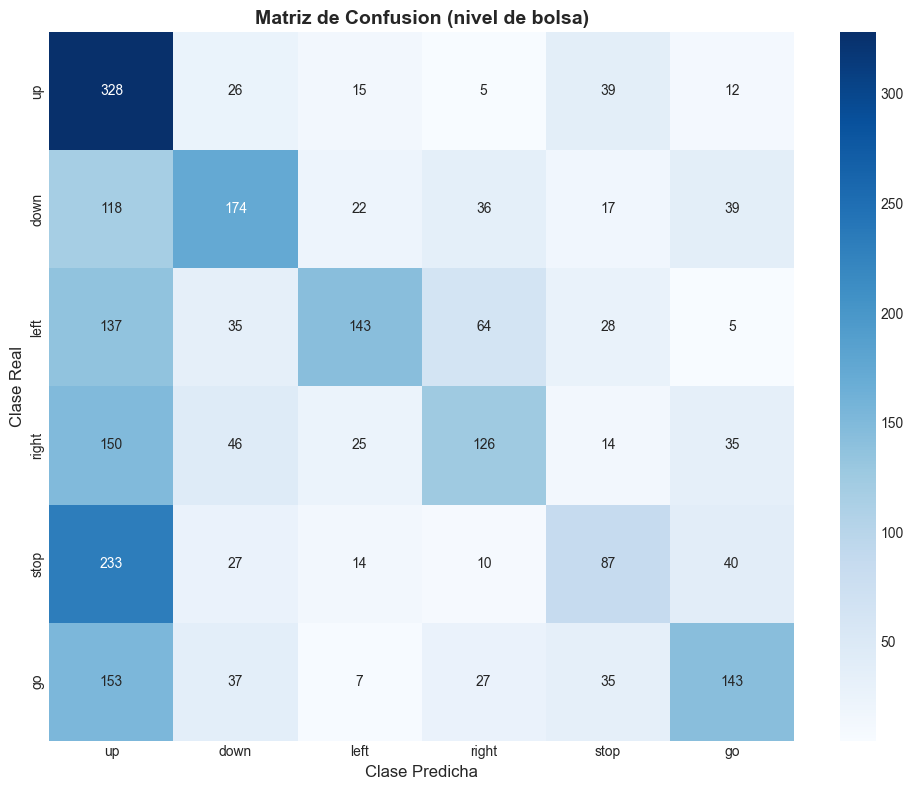


Evaluando el modelo en el conjunto de validación...
Metricas de evaluacion (nivel de bolsa):
  Accuracy  : 0.3826
  Precision : 0.4617
  Recall    : 0.3826
  F1-Score  : 0.3776

Reporte por clase:
              precision    recall  f1-score   support

          up       0.49      0.46      0.48       377
        down       0.53      0.33      0.41       372
        left       0.65      0.31      0.42       352
       right       0.51      0.23      0.31       363
        stop       0.31      0.21      0.25       350
          go       0.26      0.76      0.39       350

    accuracy                           0.38      2164
   macro avg       0.46      0.38      0.38      2164
weighted avg       0.46      0.38      0.38      2164



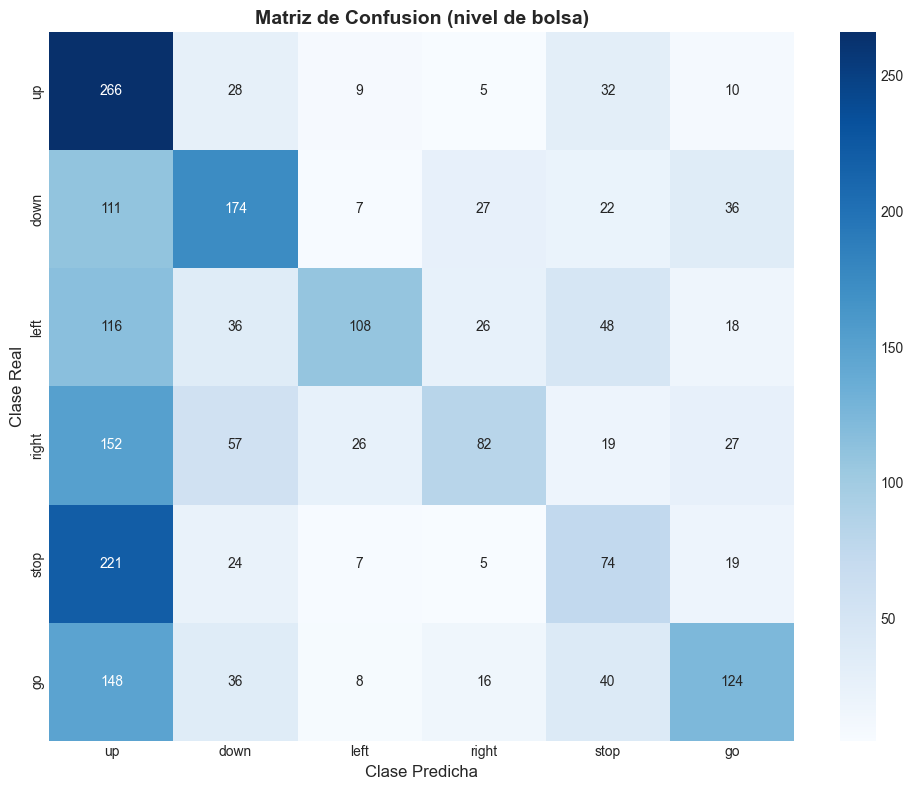

In [31]:
def evaluate_model(results, target_names=TARGET_WORDS):
    y_test_bag = results['y_test_bag']
    y_test_pred = results['y_test_pred']

    acc = accuracy_score(y_test_bag, y_test_pred)
    prec = precision_score(y_test_bag, y_test_pred, average='weighted')
    rec = recall_score(y_test_bag, y_test_pred, average='weighted')
    f1 = f1_score(y_test_bag, y_test_pred, average='weighted')

    print('Metricas de evaluacion (nivel de bolsa):')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')

    print('\nReporte por clase:')
    print(classification_report(y_test_bag, y_test_pred, target_names=target_names))

    cm = confusion_matrix(y_test_bag, y_test_pred, labels=target_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Matriz de Confusion (nivel de bolsa)', fontsize=14, fontweight='bold')
    plt.ylabel('Clase Real', fontsize=12)
    plt.xlabel('Clase Predicha', fontsize=12)
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm}

print('\nEvaluando el modelo en el conjunto de prueba...')
metrics = evaluate_model(results, target_names=TARGET_WORDS)
print('\nEvaluando el modelo en el conjunto de validación...')
metrics_val = evaluate_model(
    {
        'y_test_bag' : results['y_val_bag'],
        'y_test_pred': results['y_val_pred'],
    },
    target_names=TARGET_WORDS
)

## Analisis de las Instancias (PCA)

Para entender que tan separables son las clases en el espacio de features, proyectamos todas
las instancias a 2 dimensiones con PCA. Si las clases forman clusters visibles significa que
los MFCCs estan capturando caracteristicas discriminativas. Esta visualizacion tambien anticipa
posibles confusiones del modelo — por ejemplo, *left* y *right* comparten estructura fonetica
y es esperable que sus clusters se solapen.


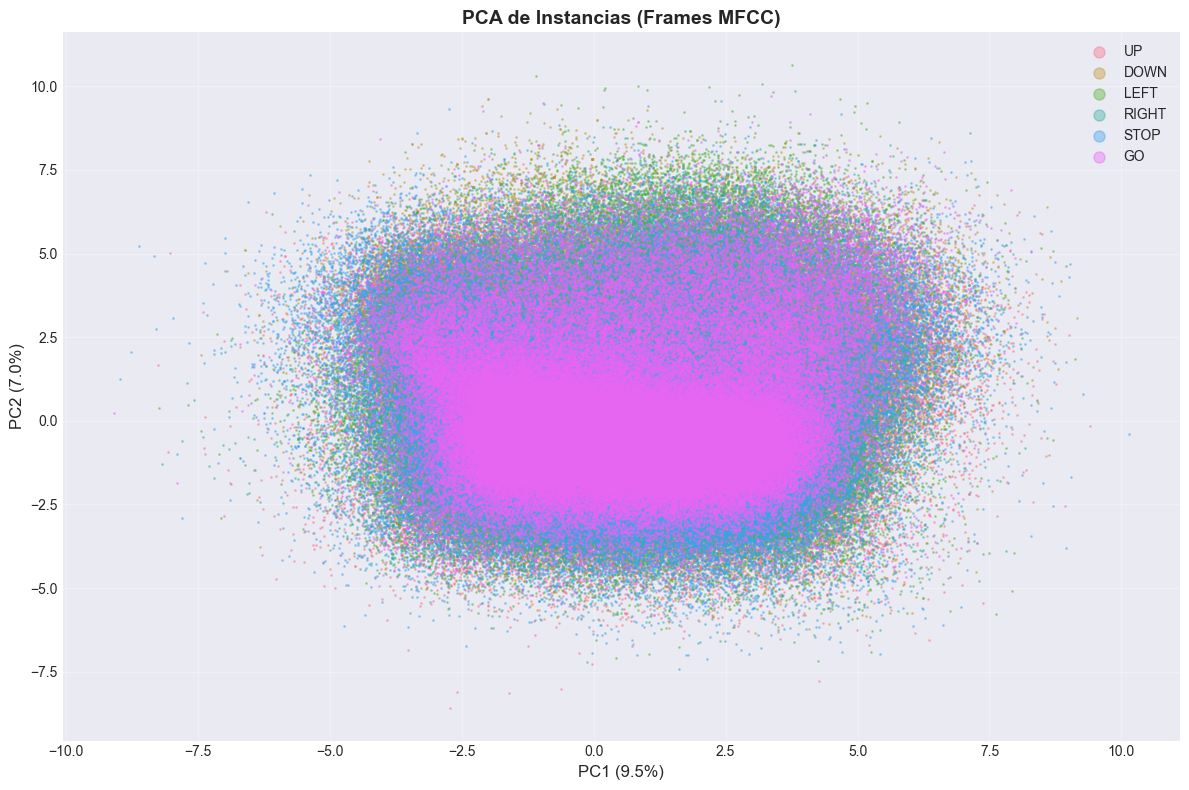

Varianza explicada (PC1+PC2) : 16.56%
Con 2 componentes (todos los disponibles) solo se alcanza 16.6% de varianza


In [ ]:
def plot_pca_instances(results, X_instances, y_instances, target_names=TARGET_WORDS):
    scaler = results['scaler']
    X_scaled = scaler.transform(X_instances)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(12, 8))
    colors = sns.color_palette('husl', len(target_names))

    for label, color in zip(target_names, colors):
        mask = y_instances == label
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label.upper(), alpha=0.4, s=1, color=color)

    plt.title('PCA de Instancias (Frames MFCC)', fontsize=14, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.legend(markerscale=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    var_acum = np.cumsum(pca.explained_variance_ratio_)
    print(f'Varianza explicada (PC1+PC2) : {sum(pca.explained_variance_ratio_[:2])*100:.2f}%')
    idx = np.argmax(var_acum >= 0.95)
    if var_acum[idx] >= 0.95:
        print(f'Componentes para 95% varianza: {idx + 1}')
    else:
        print(f'Con {len(var_acum)} componentes (todos los disponibles) solo se alcanza {var_acum[-1]*100:.1f}% de varianza')


plot_pca_instances(results, X_instances, y_instances)